#### Importing important libraries

In [80]:
import pandas as pd
import numpy as np
from  scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

### Data Loading & Data Parsing

In [81]:
df = pd.read_csv('../data/kenya.csv')

##### Adding a country column

In [82]:
df["COUNTRY"] = ["KENYA"] * len(df)

##### Convert the YEAR and DOY columns into a proper datetime column

In [83]:
df["DATETIME"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

In [ ]:
df.head()

##### Extracting Month into its own column

In [84]:
df["YEAR_MONTH"] = df["DATETIME"].dt.to_period("M")

In [10]:
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,COUNTRY,DATETIME,MONTH
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,KENYA,2015-01-01,1
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,KENYA,2015-01-02,1
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,KENYA,2015-01-03,1
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,KENYA,2015-01-04,1
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,KENYA,2015-01-05,1


### Summary Statistics & Missing-Value Report

In [11]:
df.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,COUNTRY,DATETIME,MONTH
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,KENYA,2015-01-01,1
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,KENYA,2015-01-02,1
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,KENYA,2015-01-03,1
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,KENYA,2015-01-04,1
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,KENYA,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,19.37,25.40,15.39,10.01,2.67,81.97,2.47,3.90,84.08,13.40,KENYA,2026-03-27,3
4104,2026,87,19.66,26.40,15.24,11.16,0.59,77.40,1.98,3.37,84.02,12.68,KENYA,2026-03-28,3
4105,2026,88,19.72,26.54,14.41,12.13,0.82,77.71,1.77,3.25,83.88,12.92,KENYA,2026-03-29,3
4106,2026,89,19.68,26.81,13.86,12.95,4.59,79.29,2.01,3.32,83.87,13.16,KENYA,2026-03-30,3


In [12]:
df.duplicated().sum()

np.int64(0)

`we don't have -999(null) value in our data. So we don't need to replace it with np.nan`

`We don't have duplicated row, so no need to drop any`

In [16]:
df.isnull().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
COUNTRY        0
DATETIME       0
MONTH          0
dtype: int64

##### Describe the dataset

In [17]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATETIME,MONTH
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,NaN,3.477046


`Except for PRECTOTCORR the mean and the median of the columns are quite close. `

`The 75th percentile and the max value of PRECTOTCORR is also has great gap, which suggest there might be outline on PRECTOTCORR feature.`

##### Percentage of missing values per column

In [13]:
n = len(df)
for col in df.columns:
    print(f"{col}: {df[col].isna().sum() / n * 100:.2f}%")

YEAR: 0.00%
DOY: 0.00%
T2M: 0.00%
T2M_MAX: 0.00%
T2M_MIN: 0.00%
T2M_RANGE: 0.00%
PRECTOTCORR: 0.00%
RH2M: 0.00%
WS2M: 0.00%
WS2M_MAX: 0.00%
PS: 0.00%
QV2M: 0.00%
COUNTRY: 0.00%
DATETIME: 0.00%
MONTH: 0.00%


### Outlier Detection & Basic Cleaning

##### Computing z-score for numerical columns

In [85]:
z_df = df.select_dtypes(include=[np.number]).apply(stats.zscore)

In [20]:
z_df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,MONTH
0,-1.579631,-1.685342,-0.602229,0.488146,-1.824893,1.433650,-0.461709,-2.066383,0.068262,0.387848,-0.350822,-2.596549,-1.560009
1,-1.579631,-1.675933,-0.553639,0.818867,-2.566670,2.136184,-0.461709,-2.726809,0.197201,-0.025444,-0.429950,-3.237512,-1.560009
2,-1.579631,-1.666524,-0.019158,1.158068,-2.093345,2.186090,-0.461709,-2.425792,0.466802,0.307206,-0.271693,-2.739677,-1.560009
3,-1.579631,-1.657115,0.626385,1.425189,-1.167890,1.925040,0.635830,-1.406964,-0.904645,-0.378254,-0.825595,-1.526202,-1.560009
4,-1.579631,-1.647706,-0.012217,0.712866,-1.620021,1.525785,0.101212,-1.792548,-1.514176,-0.327852,-1.458626,-2.123605,-1.560009


##### Flagging out rows with |z-score| > 3, as they're outliers and report their count 

In [86]:
for col in z_df.columns:
    count = z_df[col][z_df[col].abs() > 3].shape[0]
    print(f"{col}: {count} outliers")

YEAR: 0 outliers
DOY: 0 outliers
T2M: 8 outliers
T2M_MAX: 3 outliers
T2M_MIN: 9 outliers
T2M_RANGE: 13 outliers
PRECTOTCORR: 92 outliers
RH2M: 6 outliers
WS2M: 0 outliers
WS2M_MAX: 6 outliers
PS: 6 outliers
QV2M: 5 outliers


Apply IQR(Inner Quartile Range) to cap the outliers.

`The Interquartile Range (IQR) capping method (often called Winsorization or "clamping") is a popular way to handle outliers without losing the sample size that comes with simply deleting rows.`

In [87]:
# apply IQR method to columns with outliers
for col in z_df.columns:
    count = z_df[col][z_df[col].abs() > 3].shape[0]
    if count > 3:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

In [17]:
z_df = df.select_dtypes(include=[np.number]).apply(stats.zscore)

In [18]:
for col in z_df.columns:
    count = z_df[col][z_df[col].abs() > 3].shape[0]
    print(f"{col}: {count} outliers")

YEAR: 0 outliers
DOY: 0 outliers
T2M: 0 outliers
T2M_MAX: 3 outliers
T2M_MIN: 0 outliers
T2M_RANGE: 0 outliers
PRECTOTCORR: 0 outliers
RH2M: 0 outliers
WS2M: 0 outliers
WS2M_MAX: 0 outliers
PS: 0 outliers
QV2M: 5 outliers
MONTH: 0 outliers


##### Export z dataset

In [88]:
df.to_csv('../data/kenya_cleaned.csv', index=False)

### Time Series Analysis

In [21]:
df["YEAR_MONTH"] = df["DATETIME"].dt.to_period("M")

In [22]:
df["YEAR_MONTH"].head()

0    2015-01
1    2015-01
2    2015-01
3    2015-01
4    2015-01
Name: YEAR_MONTH, dtype: period[M]

In [28]:
monthly_t2m = (
    df.groupby("YEAR_MONTH", as_index=False)["T2M"]
      .mean()
      .rename(columns={"T2M": "T2M_MONTHLY_AVG"})
)

In [31]:
monthly_t2m.head()

,YEAR_MONTH,T2M_MONTHLY_AVG
0,2015-01,21.523226
1,2015-02,21.991429
2,2015-03,21.646452
3,2015-04,21.241667
4,2015-05,19.884194


In [34]:
warm_idx = monthly_t2m["T2M_MONTHLY_AVG"].idxmax()
cool_idx = monthly_t2m["T2M_MONTHLY_AVG"].idxmin()

warm_row = monthly_t2m.loc[warm_idx]
cool_row = monthly_t2m.loc[cool_idx]

##### Plot of monthly average T2M as a line chart over the full period

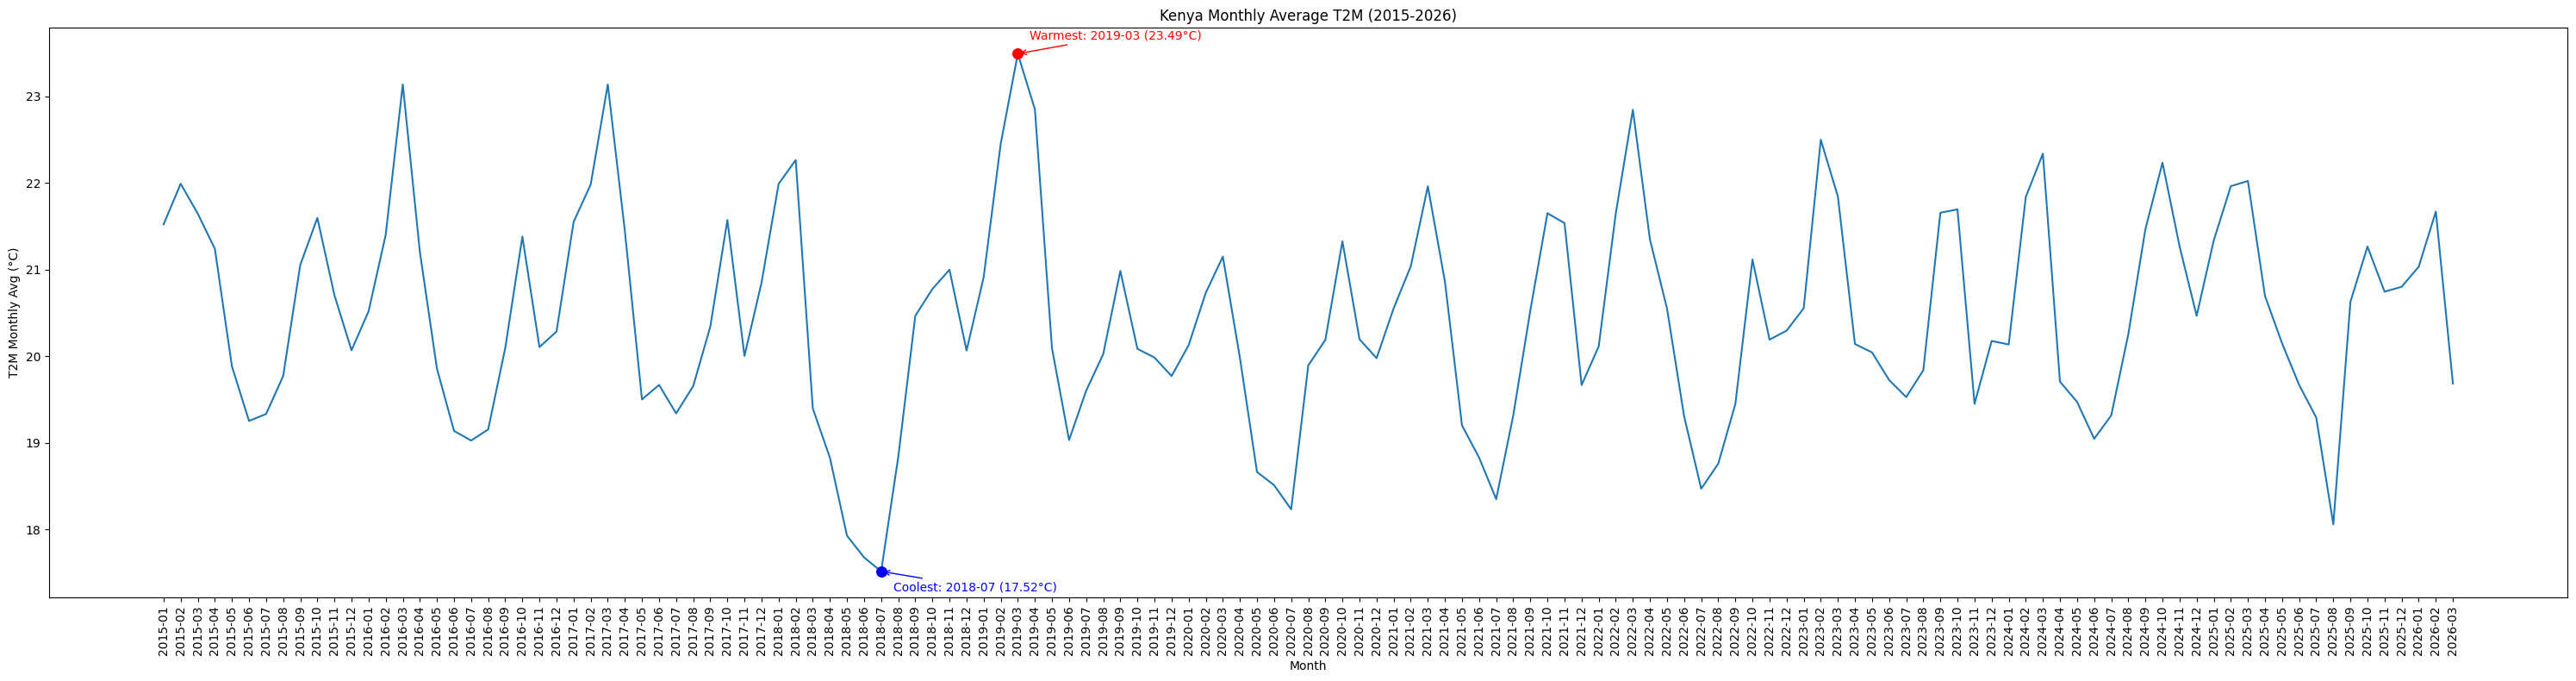

In [71]:
plt.figure(figsize=(30, 8))
x = monthly_t2m["YEAR_MONTH"].astype(str)
y = monthly_t2m["T2M_MONTHLY_AVG"]

plt.plot(x, y)

plt.scatter(x.iloc[warm_idx], y.iloc[warm_idx], color="red", s=70, zorder=5)
plt.scatter(x.iloc[cool_idx], y.iloc[cool_idx], color="blue", s=70, zorder=5)

# annotate warmest
plt.annotate(
    f"Warmest: {x.iloc[warm_idx]} ({y.iloc[warm_idx]:.2f}°C)",
    xy=(x.iloc[warm_idx], y.iloc[warm_idx]),
    xytext=(10, 12),
    textcoords="offset points",
    color="red",
    arrowprops=dict(arrowstyle="->", color="red")
)

# annotate coolest
plt.annotate(
    f"Coolest: {x.iloc[cool_idx]} ({y.iloc[cool_idx]:.2f}°C)",
    xy=(x.iloc[cool_idx], y.iloc[cool_idx]),
    xytext=(10, -16),
    textcoords="offset points",
    color="blue",
    arrowprops=dict(arrowstyle="->", color="blue")
)

plt.title("Kenya Monthly Average T2M (2015-2026)")
plt.xlabel("Month")
plt.ylabel("T2M Monthly Avg (°C)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

##### Plot monthly total PRECTOTCORR as a bar chart. 

In [57]:
monthly_prectotcorr = (
    df.groupby("YEAR_MONTH", as_index=False)["PRECTOTCORR"]
    .mean()
    .rename(columns={"PRECTOTCORR": "PRECTOTCORR_MONTHLY_AVG"}))

In [58]:
monthly_prectotcorr.head()

,YEAR_MONTH,PRECTOTCORR_MONTHLY_AVG
0,2015-01,0.222903
1,2015-02,0.446071
2,2015-03,0.705484
3,2015-04,1.697000
4,2015-05,1.077742


In [60]:
peak_rain_idx = monthly_prectotcorr["PRECTOTCORR_MONTHLY_AVG"].idxmax()

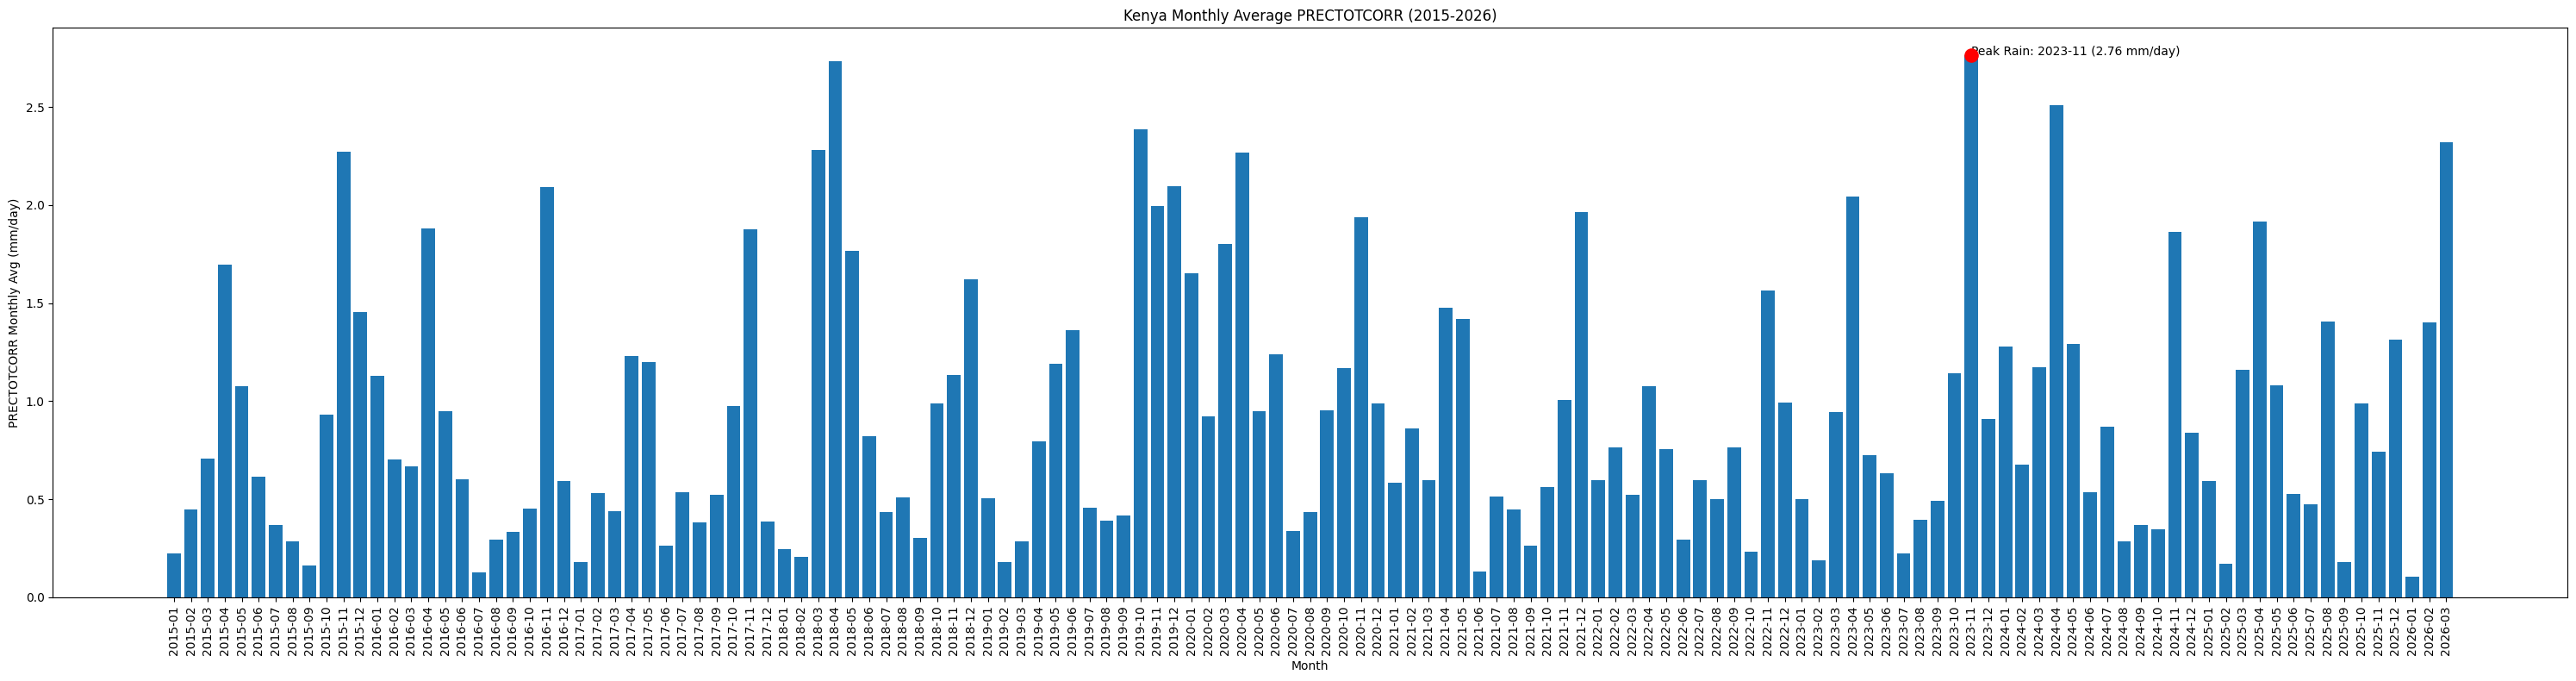

In [72]:
plt.figure(figsize=(30, 8))

plt.bar(
    monthly_prectotcorr["YEAR_MONTH"]
    .astype(str), monthly_prectotcorr["PRECTOTCORR_MONTHLY_AVG"]
    )

plt.scatter(
    monthly_prectotcorr["YEAR_MONTH"].astype(str).iloc[peak_rain_idx], 
    monthly_prectotcorr["PRECTOTCORR_MONTHLY_AVG"].iloc[peak_rain_idx], 
    color="red", s=120, zorder=5
)
plt. annotate(
    f"Peak Rain: {monthly_prectotcorr['YEAR_MONTH'].astype(str).iloc[peak_rain_idx]} ({monthly_prectotcorr['PRECTOTCORR_MONTHLY_AVG'].iloc[peak_rain_idx]:.2f} mm/day)",
    xy=(monthly_prectotcorr["YEAR_MONTH"].astype(str).iloc[peak_rain_idx], monthly_prectotcorr["PRECTOTCORR_MONTHLY_AVG"].iloc[peak_rain_idx]),
    )
plt.title("Kenya Monthly Average PRECTOTCORR (2015-2026)")
plt.xlabel("Month")
plt.ylabel("PRECTOTCORR Monthly Avg (mm/day)")
plt.xticks(rotation=90)
plt.tight_layout()

`The temperature fluctuation trend of the year seems to repeat itself year after year.`

`Months with high or low precipitation are uniform among years`

### Correlation & Relationship Analysis

##### Heatmap of correlations across all numeric columns

<Axes: >

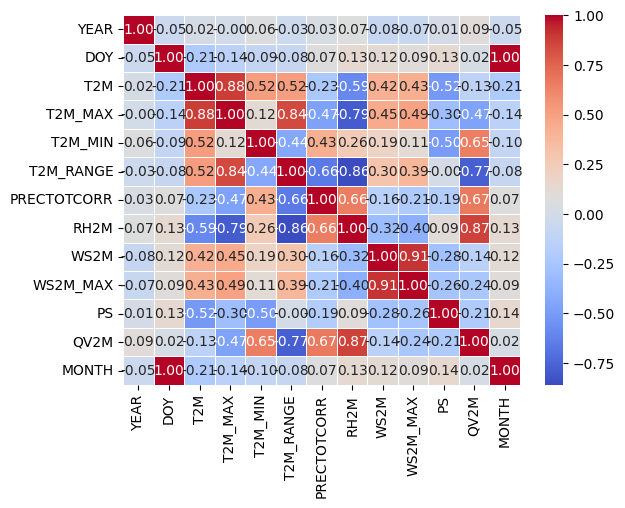

In [73]:
num_df = df.select_dtypes(include=[np.number])

corr = num_df.corr()

# heatmap of correlation matrix
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

`The three strongest correlation:`
`WS2M_MAX and WS2M == 0.91`
`T2M and T2M_MAX == 0.88`
`QV2M and RH2M == 0.87`


##### Scatter plots: T2M vs. RH2M; T2M_RANGE vs. WS2M

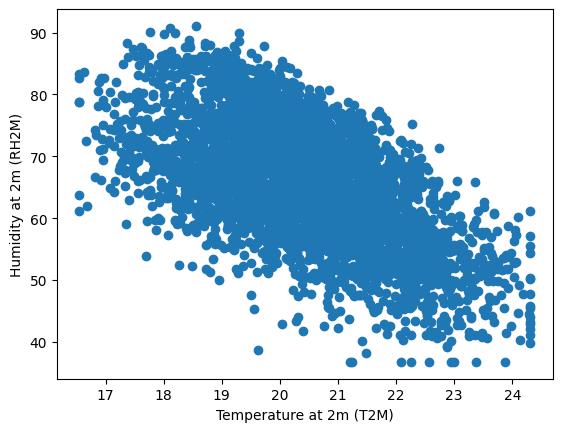

In [74]:
plt.scatter(df["T2M"], df["RH2M"])
plt.xlabel("Temperature at 2m (T2M)")
plt.ylabel("Humidity at 2m (RH2M)");

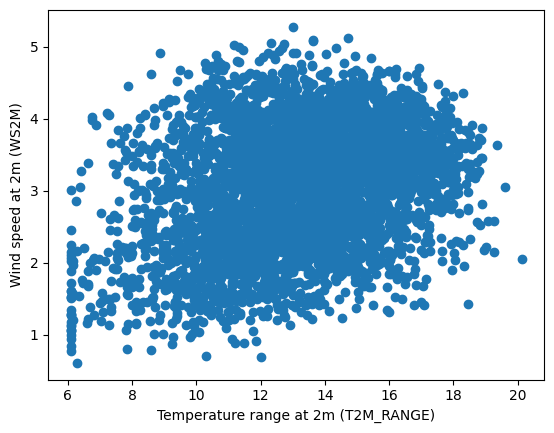

In [75]:
plt.scatter(df["T2M_RANGE"], df["WS2M"])
plt.xlabel("Temperature range at 2m (T2M_RANGE)")
plt.ylabel("Wind speed at 2m (WS2M)");  

### Distribution Analysis

##### Histogram of PRECTOTCORR

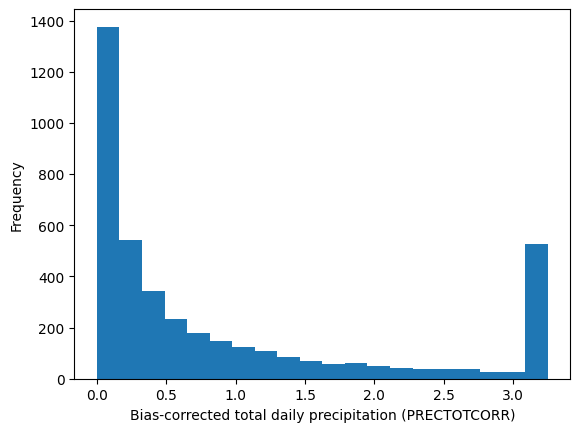

In [76]:
plt.hist(df["PRECTOTCORR"], bins=20)
plt.xlabel("Bias-corrected total daily precipitation (PRECTOTCORR)")
plt.ylabel("Frequency");

##### Applying log scaling since it's heavily skewed

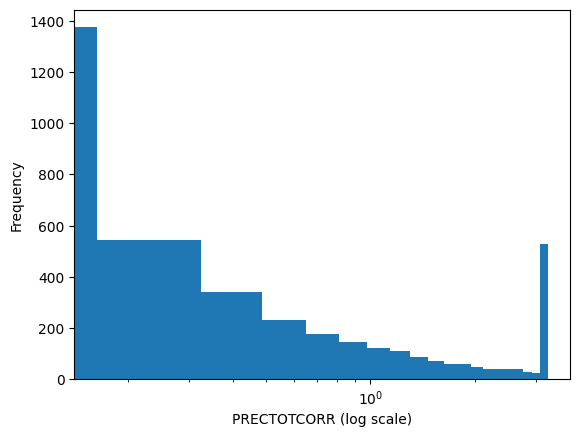

In [77]:
plt.hist(df["PRECTOTCORR"], bins=20)
plt.xscale("log")
plt.xlabel("PRECTOTCORR (log scale)")
plt.ylabel("Frequency");

##### Bubble chart: T2M vs. RH2M, bubble size = PRECTOTCORR.

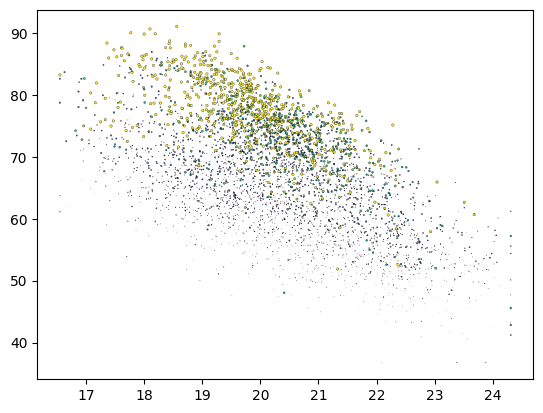

In [78]:
plt.scatter(
    df["T2M"],
    df["RH2M"],
    s=df["PRECTOTCORR"],
    c=df["PRECTOTCORR"],   # optional: color by same variable
    cmap="viridis",
    edgecolors="k",
    linewidths=0.2
)